In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import functions as F

In [2]:
# Adjust only if this notebook is not under <project_root>/notebooks
import os 
project_path = Path.cwd().parent

if str(project_path / "src") not in sys.path:
    sys.path.insert(0, str(project_path / "src"))
os.chdir(project_path)
from credit_risk.utils.config import read_config, create_path
from credit_risk.modelling.artifacts_spark import load_spark_model_artifacts
from credit_risk.modelling.data_spark import load_modelling_vintage_spark

In [3]:
config = read_config(project_path)

parameters = config["parameters"]
modelling_config = parameters["modelling"]
features_config = modelling_config["features"]

print("Modelling approach :", parameters["modelling_approach"])
print("Engine             :", parameters["engine"])
print("Algorithm          :", modelling_config["algorithm"])
print("Model version      :", modelling_config["version"])

print("\nConfigured numerical features:")
print(features_config["numerical_features"])

print("\nConfigured categorical features:")
print(features_config["categorical_features"])

print("\nConfigured engineered features:")
print(features_config["engineered_features"])

Modelling approach : behavioral
Engine             : pyspark
Algorithm          : xgboost
Model version      : test_unbalanced_quarterly

Configured numerical features:
['number_of_borrowers', 'mi_percentage', 'original_upb', 'credit_score', 'original_dti', 'original_ltv', 'original_cltv', 'current_actual_upb', 'current_interest_rate', 'estimated_ltv', 'calculated_loan_age', 'remaining_months_to_legal_maturity', 'current_non_interest_bearing_upb', 'current_interest_bearing_upb', 'non_interest_bearing_upb_pct', 'interest_bearing_upb_pct', 'current_dpd_numeric', 'max_dpd_to_date', 'delinquency_months_to_date', 'months_since_last_delinquency', 'ever_30dpd_to_date', 'ever_60dpd_to_date', 'ever_modified', 'ever_payment_deferred', 'ever_borrower_assistance', 'ever_disaster_delinquency', 'dpd_30_count_6m', 'dpd_60_count_6m', 'max_dpd_6m', 'delinquency_months_6m', 'modification_count_6m', 'payment_deferral_count_6m', 'borrower_assistance_count_6m', 'disaster_delinquency_count_6m', 'rate_step_c

In [4]:
from credit_risk.utils.spark import create_spark_session

spark = create_spark_session(config)

c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [5]:
model, preprocessor = load_spark_model_artifacts(config)

print("Model:")
print(model)

print("\nPreprocessor:")
print(preprocessor)

Model:
SparkXGBClassifier_5b23668040cc

Preprocessor:
PipelineModel_8f3738fd76e2


In [6]:
approach = parameters["modelling_approach"]

train_path = create_path(
    config["catalog"]["base"],
    config["catalog"],
    "train_df",
    approach,
    must_exist=True,
)

print("Training split:")
print(train_path)

train_df = spark.read.parquet(str(train_path))

print("Rows:", train_df.count())
print("Columns:", len(train_df.columns))

train_df.printSchema()

Training split:
data\04_model_split\behavioral\train_split.parquet
Rows: 10970334
Columns: 80
root
 |-- loan_id: string (nullable = true)
 |-- observation_age: integer (nullable = true)
 |-- period: long (nullable = true)
 |-- current_actual_upb: double (nullable = true)
 |-- current_interest_rate: double (nullable = true)
 |-- loan_age: long (nullable = true)
 |-- remaining_months_to_legal_maturity: long (nullable = true)
 |-- estimated_ltv: long (nullable = true)
 |-- current_loan_delinquency_status: string (nullable = true)
 |-- ddlpi: long (nullable = true)
 |-- modification_flag: string (nullable = true)
 |-- current_non_interest_bearing_upb: double (nullable = true)
 |-- current_interest_bearing_upb: double (nullable = true)
 |-- interest_rate_step_indicator: string (nullable = true)
 |-- payment_deferral_flag: string (nullable = true)
 |-- delinquency_due_to_disaster: string (nullable = true)
 |-- borrower_assistance_plan: string (nullable = true)
 |-- mi_cancellation_indicator:

In [7]:
from credit_risk.modelling.preprocessing_spark import prepare_features_spark

X_columns = (
    features_config["numerical_features"]
    + features_config["categorical_features"]
    + features_config["engineered_features"]
)

X_train = train_df.select(*X_columns)

X_train_prepared = prepare_features_spark(
    X_train,
    config,
)

X_train_transformed = preprocessor.transform(
    X_train_prepared,
)

X_train_transformed.select("features").printSchema()

root
 |-- features: vector (nullable = true)



In [8]:
from credit_risk.modelling.preprocessing_spark import prepare_features_spark

X_columns = (
    features_config["numerical_features"]
    + features_config["categorical_features"]
    + features_config["engineered_features"]
)

X_train = train_df.select(*X_columns)

X_train_prepared = prepare_features_spark(
    X_train,
    config,
)

X_train_transformed = preprocessor.transform(
    X_train_prepared,
)

X_train_transformed.select("features").printSchema()

root
 |-- features: vector (nullable = true)



In [11]:
features_metadata = X_train_transformed.schema["features"].metadata

ml_attr = features_metadata["ml_attr"]

attrs = []

for attr_type in ["numeric", "binary"]:
    for attr in ml_attr.get("attrs", {}).get(attr_type, []):
        attrs.append(attr)

attrs = sorted(
    attrs,
    key=lambda x: x["idx"],
)

feature_metadata = pd.DataFrame(attrs)

print(feature_metadata)

                                              name  idx
0                    __imputed_number_of_borrowers    0
1                          __imputed_mi_percentage    1
2                           __imputed_original_upb    2
3                           __imputed_credit_score    3
4                           __imputed_original_dti    4
..                                             ...  ...
149          __encoded_mi_cancellation_indicator_7  149
150          __encoded_mi_cancellation_indicator_N  150
151          __encoded_mi_cancellation_indicator_Y  151
152  __encoded_mi_cancellation_indicator___unknown  152
153                           original_dti_missing  153

[154 rows x 2 columns]


In [12]:
booster = model.get_booster()

gain_importance = booster.get_score(importance_type="gain")

weight_importance = booster.get_score(importance_type="weight")

cover_importance = booster.get_score(importance_type="cover")

print("Number of XGBoost features with non-zero gain:")
print(len(gain_importance))

Number of XGBoost features with non-zero gain:
89


In [13]:
def importance_to_dataframe(
    importance_dict,
    importance_name,
):
    rows = []

    for feature_key, importance in importance_dict.items():

        if not feature_key.startswith("f"):
            continue

        idx = int(feature_key[1:])

        match = feature_metadata[feature_metadata["idx"] == idx]

        if match.empty:
            feature_name = feature_key
        else:
            feature_name = match.iloc[0]["name"]

        rows.append(
            {
                "xgb_feature": feature_key,
                "feature_index": idx,
                "feature_name": feature_name,
                importance_name: importance,
            }
        )

    return pd.DataFrame(rows)


gain_df = importance_to_dataframe(
    gain_importance,
    "gain",
)

weight_df = importance_to_dataframe(
    weight_importance,
    "weight",
)

cover_df = importance_to_dataframe(
    cover_importance,
    "cover",
)

In [14]:
def importance_to_dataframe(
    importance_dict,
    importance_name,
):
    rows = []

    for feature_key, importance in importance_dict.items():

        if not feature_key.startswith("f"):
            continue

        idx = int(feature_key[1:])

        match = feature_metadata[feature_metadata["idx"] == idx]

        if match.empty:
            feature_name = feature_key
        else:
            feature_name = match.iloc[0]["name"]

        rows.append(
            {
                "xgb_feature": feature_key,
                "feature_index": idx,
                "feature_name": feature_name,
                importance_name: importance,
            }
        )

    return pd.DataFrame(rows)


gain_df = importance_to_dataframe(
    gain_importance,
    "gain",
)

weight_df = importance_to_dataframe(
    weight_importance,
    "weight",
)

cover_df = importance_to_dataframe(
    cover_importance,
    "cover",
)

In [15]:
importance_df = gain_df.merge(
    weight_df,
    on=[
        "xgb_feature",
        "feature_index",
        "feature_name",
    ],
    how="outer",
)

importance_df = importance_df.merge(
    cover_df,
    on=[
        "xgb_feature",
        "feature_index",
        "feature_name",
    ],
    how="outer",
)

importance_df = importance_df.fillna(0)

importance_df = importance_df.sort_values(
    "gain",
    ascending=False,
)

importance_df.head(30)

,xgb_feature,feature_index,feature_name,gain,weight,cover
37,f29,29,__imputed_delinquency_months_6m,5747.026855,63.0,12921.736328
33,f19,19,__imputed_months_since_last_delinquency,2314.044922,66.0,8844.193359
36,f28,28,__imputed_max_dpd_6m,1877.875977,116.0,7554.993652
40,f37,37,__imputed_max_dpd_12m,1817.726807,80.0,21096.197266
24,f145,145,__encoded_borrower_assistance_plan_F,1620.779907,13.0,466.779022
72,f8,8,__imputed_current_interest_rate,861.583130,526.0,11475.839844
2,f10,10,__imputed_calculated_loan_age,716.184143,138.0,16014.349609
69,f77,77,__encoded_property_state_FL,517.349243,169.0,17311.783203
38,f3,3,__imputed_credit_score,464.163544,416.0,13589.600586
41,f38,38,__imputed_delinquency_months_12m,400.863556,32.0,10145.172852


In [16]:
importance_df = gain_df.merge(
    weight_df,
    on=[
        "xgb_feature",
        "feature_index",
        "feature_name",
    ],
    how="outer",
)

importance_df = importance_df.merge(
    cover_df,
    on=[
        "xgb_feature",
        "feature_index",
        "feature_name",
    ],
    how="outer",
)

importance_df = importance_df.fillna(0)

importance_df = importance_df.sort_values(
    "gain",
    ascending=False,
)

importance_df.head(30)

,xgb_feature,feature_index,feature_name,gain,weight,cover
37,f29,29,__imputed_delinquency_months_6m,5747.026855,63.0,12921.736328
33,f19,19,__imputed_months_since_last_delinquency,2314.044922,66.0,8844.193359
36,f28,28,__imputed_max_dpd_6m,1877.875977,116.0,7554.993652
40,f37,37,__imputed_max_dpd_12m,1817.726807,80.0,21096.197266
24,f145,145,__encoded_borrower_assistance_plan_F,1620.779907,13.0,466.779022
72,f8,8,__imputed_current_interest_rate,861.583130,526.0,11475.839844
2,f10,10,__imputed_calculated_loan_age,716.184143,138.0,16014.349609
69,f77,77,__encoded_property_state_FL,517.349243,169.0,17311.783203
38,f3,3,__imputed_credit_score,464.163544,416.0,13589.600586
41,f38,38,__imputed_delinquency_months_12m,400.863556,32.0,10145.172852


In [17]:
all_model_features = (
    features_config["numerical_features"]
    + features_config["categorical_features"]
    + features_config["engineered_features"]
)


def original_feature_name(transformed_name):
    """
    Convert Spark preprocessing output names back to the
    original configured modelling feature.
    """

    name = transformed_name

    # Numerical imputation
    if name.startswith("__imputed_"):
        name = name.replace(
            "__imputed_",
            "",
            1,
        )

    # One-hot encoded categorical feature
    elif name.startswith("__encoded_"):
        name = name.replace(
            "__encoded_",
            "",
            1,
        )

        for feature in features_config["categorical_features"]:
            if name == feature or name.startswith(feature + "_"):
                return feature

    # Fallback exact match
    if name in all_model_features:
        return name

    # Engineered features
    for feature in features_config["engineered_features"]:
        if name == feature:
            return feature

    return name


importance_df["original_feature"] = importance_df["feature_name"].apply(
    original_feature_name
)

importance_df.head(30)

,xgb_feature,feature_index,feature_name,gain,weight,cover,original_feature
37,f29,29,__imputed_delinquency_months_6m,5747.026855,63.0,12921.736328,delinquency_months_6m
33,f19,19,__imputed_months_since_last_delinquency,2314.044922,66.0,8844.193359,months_since_last_delinquency
36,f28,28,__imputed_max_dpd_6m,1877.875977,116.0,7554.993652,max_dpd_6m
40,f37,37,__imputed_max_dpd_12m,1817.726807,80.0,21096.197266,max_dpd_12m
24,f145,145,__encoded_borrower_assistance_plan_F,1620.779907,13.0,466.779022,borrower_assistance_plan
72,f8,8,__imputed_current_interest_rate,861.583130,526.0,11475.839844,current_interest_rate
2,f10,10,__imputed_calculated_loan_age,716.184143,138.0,16014.349609,calculated_loan_age
69,f77,77,__encoded_property_state_FL,517.349243,169.0,17311.783203,property_state
38,f3,3,__imputed_credit_score,464.163544,416.0,13589.600586,credit_score
41,f38,38,__imputed_delinquency_months_12m,400.863556,32.0,10145.172852,delinquency_months_12m


In [18]:
aggregated_importance = (
    importance_df.groupby("original_feature", as_index=False)
    .agg(
        gain=("gain", "sum"),
        weight=("weight", "sum"),
        cover=("cover", "sum"),
    )
    .sort_values(
        "gain",
        ascending=False,
    )
)

aggregated_importance["gain_pct"] = (
    aggregated_importance["gain"] / aggregated_importance["gain"].sum() * 100
)

aggregated_importance["cumulative_gain_pct"] = aggregated_importance[
    "gain_pct"
].cumsum()

aggregated_importance.head(30)

,original_feature,gain,weight,cover,gain_pct,cumulative_gain_pct
10,delinquency_months_6m,5747.026855,63.0,12921.736328,27.231463,27.231463
24,months_since_last_delinquency,2314.044922,66.0,8844.193359,10.964770,38.196233
20,max_dpd_6m,1877.875977,116.0,7554.993652,8.898046,47.094279
19,max_dpd_12m,1817.726807,80.0,21096.197266,8.613038,55.707317
32,property_state,1791.835672,602.0,830723.983498,8.490356,64.197674
0,borrower_assistance_plan,1684.940039,36.0,41080.535126,7.983847,72.181521
7,current_interest_rate,861.583130,526.0,11475.839844,4.082488,76.264009
1,calculated_loan_age,716.184143,138.0,16014.349609,3.393536,79.657545
26,occupancy_status,579.646922,64.0,52466.587570,2.746574,82.404118
3,credit_score,464.163544,416.0,13589.600586,2.199372,84.603491


In [19]:
aggregated_importance = (
    importance_df.groupby("original_feature", as_index=False)
    .agg(
        gain=("gain", "sum"),
        weight=("weight", "sum"),
        cover=("cover", "sum"),
    )
    .sort_values(
        "gain",
        ascending=False,
    )
)

aggregated_importance["gain_pct"] = (
    aggregated_importance["gain"] / aggregated_importance["gain"].sum() * 100
)

aggregated_importance["cumulative_gain_pct"] = aggregated_importance[
    "gain_pct"
].cumsum()

aggregated_importance.head(30)

,original_feature,gain,weight,cover,gain_pct,cumulative_gain_pct
10,delinquency_months_6m,5747.026855,63.0,12921.736328,27.231463,27.231463
24,months_since_last_delinquency,2314.044922,66.0,8844.193359,10.964770,38.196233
20,max_dpd_6m,1877.875977,116.0,7554.993652,8.898046,47.094279
19,max_dpd_12m,1817.726807,80.0,21096.197266,8.613038,55.707317
32,property_state,1791.835672,602.0,830723.983498,8.490356,64.197674
0,borrower_assistance_plan,1684.940039,36.0,41080.535126,7.983847,72.181521
7,current_interest_rate,861.583130,526.0,11475.839844,4.082488,76.264009
1,calculated_loan_age,716.184143,138.0,16014.349609,3.393536,79.657545
26,occupancy_status,579.646922,64.0,52466.587570,2.746574,82.404118
3,credit_score,464.163544,416.0,13589.600586,2.199372,84.603491


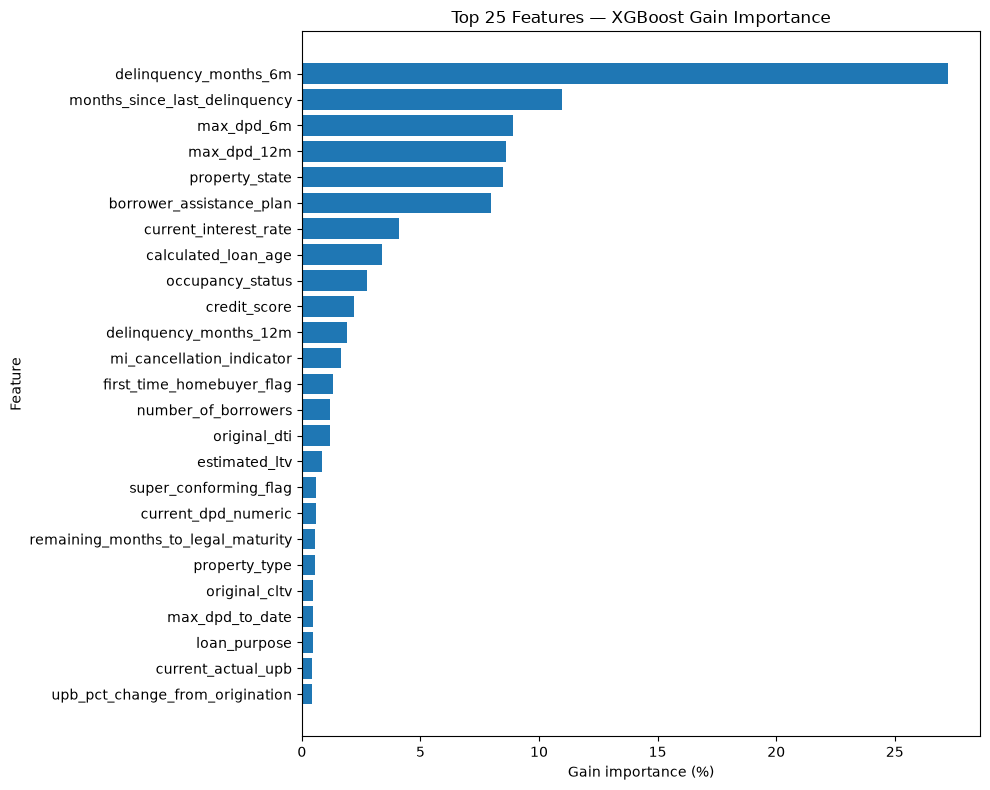

In [20]:
top_n = 25

top_features = aggregated_importance.head(top_n).sort_values("gain")

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["original_feature"],
    top_features["gain_pct"],
)

plt.xlabel("Gain importance (%)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features — XGBoost Gain Importance")

plt.tight_layout()
plt.show()

In [21]:
numerical_features = set(features_config["numerical_features"])

categorical_features = set(features_config["categorical_features"])

engineered_features = set(features_config["engineered_features"])


def feature_group(feature):

    if feature in numerical_features:
        return "Numerical"

    if feature in categorical_features:
        return "Categorical"

    if feature in engineered_features:
        return "Engineered"

    return "Other"


aggregated_importance["feature_group"] = aggregated_importance[
    "original_feature"
].apply(feature_group)

group_importance = aggregated_importance.groupby("feature_group", as_index=False)[
    "gain"
].sum()

group_importance["gain_pct"] = (
    group_importance["gain"] / group_importance["gain"].sum() * 100
)

group_importance.sort_values(
    "gain",
    ascending=False,
)

,feature_group,gain,gain_pct
2,Numerical,15863.462898,75.166745
0,Categorical,5189.630887,24.590322
1,Engineered,51.269424,0.242933


In [22]:
origination_features = {
    "number_of_borrowers",
    "mi_percentage",
    "original_upb",
    "credit_score",
    "original_dti",
    "original_ltv",
    "original_cltv",
    "original_interest_rate",
    "original_loan_term",
    "first_time_homebuyer_flag",
    "property_type",
    "occupancy_status",
    "loan_purpose",
    "channel",
    "super_conforming_flag",
    "harp_indicator",
    "property_state",
    "original_dti_missing",
}

behavioral_features = set(all_model_features) - origination_features


def modelling_feature_group(feature):

    if feature in origination_features:
        return "Origination"

    if feature in behavioral_features:
        return "Behavioral"

    return "Other"


aggregated_importance["modelling_group"] = aggregated_importance[
    "original_feature"
].apply(modelling_feature_group)

group_importance = aggregated_importance.groupby("modelling_group", as_index=False)[
    "gain"
].sum()

group_importance["gain_pct"] = (
    group_importance["gain"] / group_importance["gain"].sum() * 100
)

group_importance.sort_values(
    "gain",
    ascending=False,
)

,modelling_group,gain,gain_pct
0,Behavioral,16755.801537,79.394964
1,Origination,4348.561673,20.605036


In [23]:
behavioral_importance = aggregated_importance[
    aggregated_importance["modelling_group"] == "Behavioral"
].sort_values(
    "gain",
    ascending=False,
)

behavioral_importance[
    [
        "original_feature",
        "gain_pct",
        "weight",
        "cover",
    ]
].head(30)

,original_feature,gain_pct,weight,cover
10,delinquency_months_6m,27.231463,63.0,12921.736328
24,months_since_last_delinquency,10.964770,66.0,8844.193359
20,max_dpd_6m,8.898046,116.0,7554.993652
19,max_dpd_12m,8.613038,80.0,21096.197266
0,borrower_assistance_plan,7.983847,36.0,41080.535126
7,current_interest_rate,4.082488,526.0,11475.839844
1,calculated_loan_age,3.393536,138.0,16014.349609
9,delinquency_months_12m,1.899435,32.0,10145.172852
22,mi_cancellation_indicator,1.646167,16.0,3212.196022
14,estimated_ltv,0.854266,168.0,13125.576172


In [24]:
origination_importance = aggregated_importance[
    aggregated_importance["modelling_group"] == "Origination"
].sort_values(
    "gain",
    ascending=False,
)

origination_importance[
    [
        "original_feature",
        "gain_pct",
        "weight",
        "cover",
    ]
].head(30)

,original_feature,gain_pct,weight,cover
32,property_state,8.490356,602.0,830723.983498
26,occupancy_status,2.746574,64.0,52466.587570
3,credit_score,2.199372,416.0,13589.600586
16,first_time_homebuyer_flag,1.333237,45.0,20759.932617
25,number_of_borrowers,1.186727,181.0,18770.277344
28,original_dti,1.182062,248.0,18008.462891
35,super_conforming_flag,0.606304,13.0,34301.830078
33,property_type,0.536692,59.0,19522.037537
27,original_cltv,0.484871,210.0,9977.750977
18,loan_purpose,0.452375,95.0,19894.079346


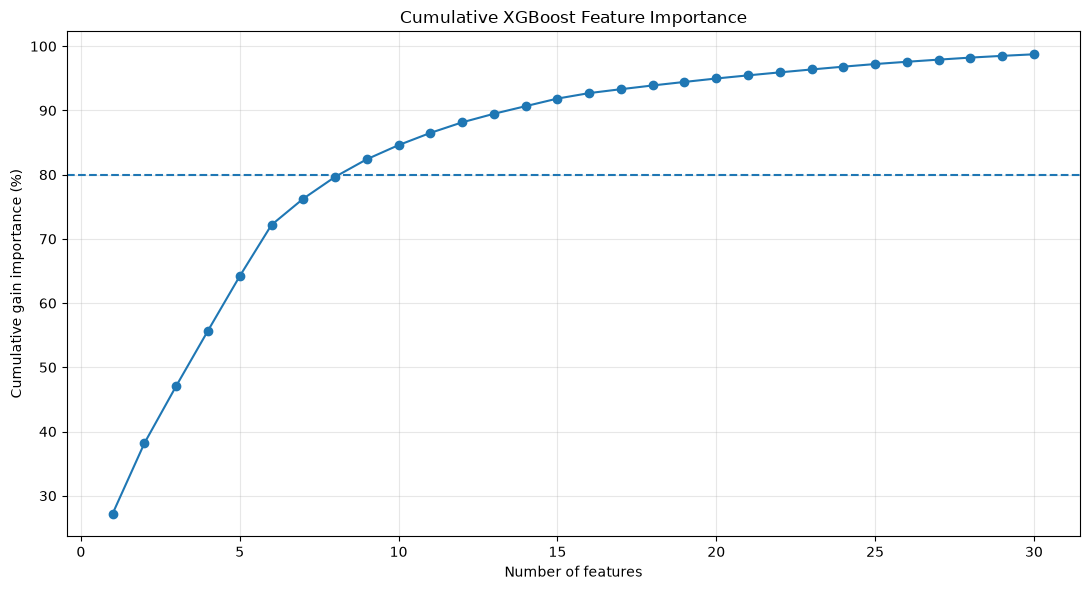

In [25]:
top_features = aggregated_importance.head(30)

plt.figure(figsize=(11, 6))

plt.plot(
    range(1, len(top_features) + 1),
    top_features["cumulative_gain_pct"],
    marker="o",
)

plt.axhline(
    80,
    linestyle="--",
)

plt.xlabel("Number of features")
plt.ylabel("Cumulative gain importance (%)")
plt.title("Cumulative XGBoost Feature Importance")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
importance_table = (
    aggregated_importance[
        [
            "original_feature",
            "feature_group",
            "modelling_group",
            "gain",
            "gain_pct",
            "cumulative_gain_pct",
            "weight",
            "cover",
        ]
    ]
    .sort_values(
        "gain",
        ascending=False,
    )
    .reset_index(drop=True)
)

importance_table

,original_feature,feature_group,modelling_group,gain,gain_pct,cumulative_gain_pct,weight,cover
0,delinquency_months_6m,Numerical,Behavioral,5747.026855,27.231463,27.231463,63.0,12921.736328
1,months_since_last_delinquency,Numerical,Behavioral,2314.044922,10.964770,38.196233,66.0,8844.193359
2,max_dpd_6m,Numerical,Behavioral,1877.875977,8.898046,47.094279,116.0,7554.993652
3,max_dpd_12m,Numerical,Behavioral,1817.726807,8.613038,55.707317,80.0,21096.197266
4,property_state,Categorical,Origination,1791.835672,8.490356,64.197674,602.0,830723.983498
5,borrower_assistance_plan,Categorical,Behavioral,1684.940039,7.983847,72.181521,36.0,41080.535126
6,current_interest_rate,Numerical,Behavioral,861.583130,4.082488,76.264009,526.0,11475.839844
7,calculated_loan_age,Numerical,Behavioral,716.184143,3.393536,79.657545,138.0,16014.349609
8,occupancy_status,Categorical,Origination,579.646922,2.746574,82.404118,64.0,52466.587570
9,credit_score,Numerical,Origination,464.163544,2.199372,84.603491,416.0,13589.600586


In [36]:
# ============================================================
# BUSINESS FEATURE GROUPS
# ============================================================

feature_groups = {
    # Delinquency / behavioural history
    "Delinquency_Recent": [
        "current_dpd_numeric",
        "dpd_30_count_6m",
        "dpd_60_count_6m",
        "max_dpd_6m",
        "delinquency_months_6m",
        "dpd_30_count_12m",
        "dpd_60_count_12m",
        "max_dpd_12m",
        "delinquency_months_12m",
    ],
    "Delinquency_Lifetime": [
        "max_dpd_to_date",
        "delinquency_months_to_date",
        "months_since_last_delinquency",
        "ever_30dpd_to_date",
        "ever_60dpd_to_date",
    ],
    "Assistance_Modification": [
        "modification_flag",
        "payment_deferral_flag",
        "borrower_assistance_plan",
        "ever_modified",
        "ever_payment_deferred",
        "ever_borrower_assistance",
        "modification_count_6m",
        "payment_deferral_count_6m",
        "borrower_assistance_count_6m",
        "modification_count_12m",
        "payment_deferral_count_12m",
        "borrower_assistance_count_12m",
    ],
    "Disaster": [
        "delinquency_due_to_disaster",
        "ever_disaster_delinquency",
        "disaster_delinquency_count_6m",
        "disaster_delinquency_count_12m",
    ],
    "Rate": [
        "current_interest_rate",
        "rate_change_from_origination",
        "interest_rate_step_indicator",
        "rate_step_count_6m",
        "rate_step_count_12m",
    ],
    "Balance": [
        "current_actual_upb",
        "current_non_interest_bearing_upb",
        "current_interest_bearing_upb",
        "non_interest_bearing_upb_pct",
        "interest_bearing_upb_pct",
        "upb_pct_change_from_origination",
    ],
    "Lifecycle": [
        "calculated_loan_age",
        "remaining_months_to_legal_maturity",
    ],
    "Origination_Credit": [
        "credit_score",
        "original_dti",
        "original_ltv",
        "original_cltv",
        "mi_percentage",
        "number_of_borrowers",
    ],
    "Origination_Loan": [
        "original_upb",
        "original_interest_rate",
        "original_loan_term",
    ],
    "Origination_Property": [
        "property_state",
        "property_type",
        "occupancy_status",
        "first_time_homebuyer_flag",
    ],
    "Origination_Purpose": [
        "loan_purpose",
        "channel",
        "super_conforming_flag",
        "harp_indicator",
    ],
    "Insurance": [
        "mi_cancellation_indicator",
        "estimated_ltv",
    ],
    "Engineered": [
        "original_dti_missing",
    ],
}

In [38]:
# ============================================================
# BUSINESS FEATURE GROUP IMPORTANCE
# ============================================================

# Work from the actual importance dataframe
importance_grouped = importance_df.copy()

# Make sure gain_pct exists
if "gain_pct" not in importance_grouped.columns:
    total_gain = importance_grouped["gain"].sum()

    importance_grouped["gain_pct"] = importance_grouped["gain"] / total_gain * 100

# Map individual features to business groups
feature_to_group = {
    feature: group for group, features in feature_groups.items() for feature in features
}

importance_grouped["business_group"] = (
    importance_grouped["original_feature"].map(feature_to_group).fillna("Other")
)

# Aggregate
group_summary = (
    importance_grouped.groupby("business_group", as_index=False)
    .agg(
        gain=("gain", "sum"),
        gain_pct=("gain_pct", "sum"),
        weight=("weight", "sum"),
    )
    .sort_values("gain_pct", ascending=False)
    .reset_index(drop=True)
)

group_summary

,business_group,gain,gain_pct,weight
0,Delinquency_Recent,9966.499245,47.224828,402.0
1,Origination_Property,2766.119267,13.106860,770.0
2,Delinquency_Lifetime,2444.922928,11.584917,151.0
3,Assistance_Modification,1684.940039,7.983847,36.0
4,Origination_Credit,1167.082367,5.530053,1212.0
5,Rate,861.583130,4.082488,526.0
6,Lifecycle,831.883690,3.941762,260.0
7,Insurance,527.700390,2.500433,184.0
8,Origination_Purpose,316.614471,1.500232,177.0
9,Balance,248.771400,1.178768,506.0


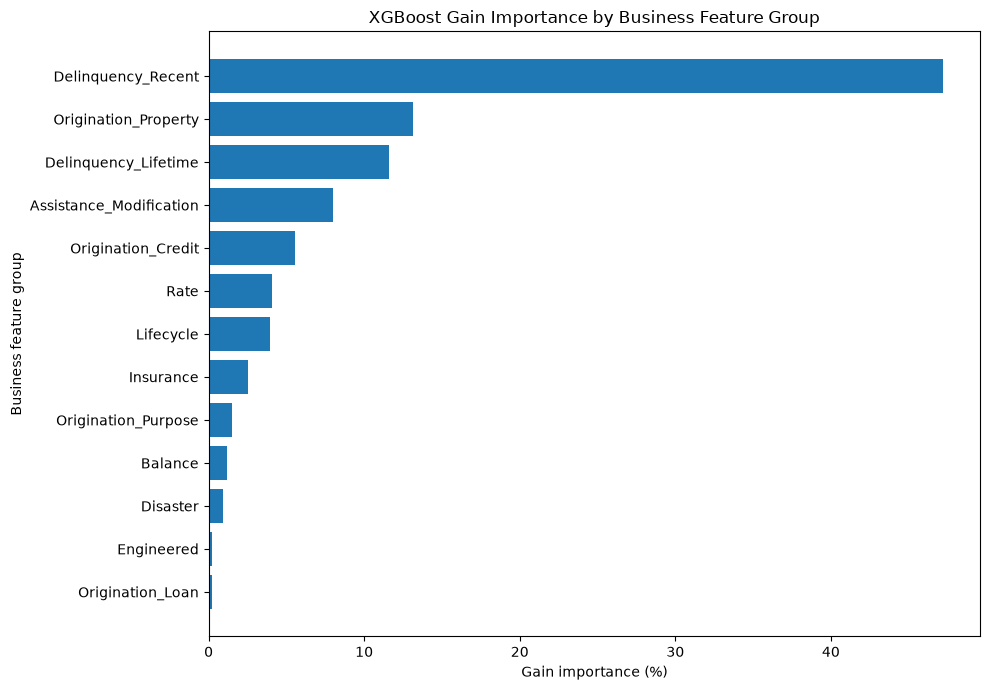

In [39]:
plt.figure(figsize=(10, 7))

plot_df = group_summary.sort_values("gain_pct", ascending=True)

plt.barh(
    plot_df["business_group"],
    plot_df["gain_pct"],
)

plt.xlabel("Gain importance (%)")
plt.ylabel("Business feature group")
plt.title("XGBoost Gain Importance by Business Feature Group")

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# OOT DATA FOR FEATURE STABILITY TEST
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import pandas as pd

oot_vintages = parameters["modelling"]["vintages_oot"]

print("OOT vintages:", oot_vintages)

oot_df = load_modelling_vintage_spark(
    spark,
    config,
    oot_vintages,
)

print("OOT columns:", len(oot_df.columns))
oot_df.printSchema()

OOT vintages: [2021, 2022]
OOT columns: 80
root
 |-- loan_id: string (nullable = true)
 |-- observation_age: integer (nullable = true)
 |-- period: long (nullable = true)
 |-- current_actual_upb: double (nullable = true)
 |-- current_interest_rate: double (nullable = true)
 |-- loan_age: long (nullable = true)
 |-- remaining_months_to_legal_maturity: long (nullable = true)
 |-- estimated_ltv: long (nullable = true)
 |-- current_loan_delinquency_status: string (nullable = true)
 |-- ddlpi: long (nullable = true)
 |-- modification_flag: string (nullable = true)
 |-- current_non_interest_bearing_upb: double (nullable = true)
 |-- current_interest_bearing_upb: double (nullable = true)
 |-- interest_rate_step_indicator: string (nullable = true)
 |-- payment_deferral_flag: string (nullable = true)
 |-- delinquency_due_to_disaster: string (nullable = true)
 |-- borrower_assistance_plan: string (nullable = true)
 |-- mi_cancellation_indicator: string (nullable = true)
 |-- servicer_name: strin

In [41]:
# ============================================================
# FIXED OOT SAMPLE
# ============================================================

OOT_SAMPLE_SIZE = 150_000
RANDOM_SEED = 42

oot_sample = oot_df.orderBy(F.rand(RANDOM_SEED)).limit(OOT_SAMPLE_SIZE).cache()

sample_count = oot_sample.count()

print(f"OOT sample rows: {sample_count:,}")

OOT sample rows: 150,000


In [42]:
# ============================================================
# MODEL INPUT FEATURES
# ============================================================

X_columns = (
    features_config["numerical_features"]
    + features_config["categorical_features"]
    + features_config["engineered_features"]
)

target = parameters["target"]["name"]

print("Number of configured raw features:", len(X_columns))
print("Target:", target)

Number of configured raw features: 61
Target: future_90dpd_12m


In [44]:
# ============================================================
# BASELINE OOT PREDICTIONS
# ============================================================

from credit_risk.modelling.preprocessing_spark import prepare_features_spark

# Keep the target alongside the raw model inputs.
# The target is NOT included in X_columns.
X_oot = oot_sample.select(
    *X_columns,
    target,
)

X_oot_prepared = prepare_features_spark(
    X_oot,
    config,
)

# The preprocessing pipeline should preserve the target column
# while creating the transformed `features` vector.
X_oot_transformed = preprocessor.transform(
    X_oot_prepared,
)

oot_model_input = X_oot_transformed.select(
    "features",
    F.col(target).cast("double").alias("label"),
).cache()

print("Model input schema:")
oot_model_input.printSchema()

Model input schema:
root
 |-- features: vector (nullable = true)
 |-- label: double (nullable = true)



In [49]:
from pyspark.ml.functions import vector_to_array

# ============================================================
# BASELINE PREDICTIONS
# ============================================================

baseline_predictions = model.transform(oot_model_input).select(
    "label",
    vector_to_array("probability").getItem(1).alias("prediction"),
)

baseline_pd = baseline_predictions.toPandas()

baseline_auc = roc_auc_score(
    baseline_pd["label"],
    baseline_pd["prediction"],
)

baseline_pr_auc = average_precision_score(
    baseline_pd["label"],
    baseline_pd["prediction"],
)

print(f"Baseline OOT ROC-AUC : {baseline_auc:.6f}")
print(f"Baseline OOT PR-AUC  : {baseline_pr_auc:.6f}")

c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Baseline OOT ROC-AUC : 0.826395
Baseline OOT PR-AUC  : 0.195453


In [50]:
# ============================================================
# TOP FEATURES FOR OOT PERMUTATION TEST
# ============================================================

TOP_N = 15

top_features = (
    importance_df.sort_values("gain", ascending=False)["original_feature"]
    .head(TOP_N)
    .tolist()
)

print("Features to permutation-test:\n")

for i, feature in enumerate(top_features, start=1):
    print(f"{i:2d}. {feature}")

Features to permutation-test:

 1. delinquency_months_6m
 2. months_since_last_delinquency
 3. max_dpd_6m
 4. max_dpd_12m
 5. borrower_assistance_plan
 6. current_interest_rate
 7. calculated_loan_age
 8. property_state
 9. credit_score
10. delinquency_months_12m
11. occupancy_status
12. mi_cancellation_indicator
13. number_of_borrowers
14. original_dti
15. first_time_homebuyer_flag


In [51]:
# ============================================================
# PERMUTATION HELPER
# ============================================================


def permute_raw_feature(
    df,
    feature,
    seed=42,
):
    """
    Shuffle one raw feature while preserving the values of
    every other column.

    The feature distribution is preserved; only its association
    with the other observations is destroyed.
    """

    from pyspark.sql import functions as F

    # Add a deterministic row identifier.
    df_with_id = df.withColumn(
        "_permutation_id",
        F.monotonically_increasing_id(),
    )

    # Collect ONLY the feature being permuted.
    values_pd = df_with_id.select("_permutation_id", feature).toPandas()

    # Shuffle feature values while preserving their distribution.
    shuffled_values = (
        values_pd[feature]
        .sample(
            frac=1.0,
            random_state=seed,
        )
        .reset_index(drop=True)
    )

    replacement_pd = pd.DataFrame(
        {
            "_permutation_id": values_pd["_permutation_id"].values,
            "_permuted_value": shuffled_values.values,
        }
    )

    replacement_spark = spark.createDataFrame(replacement_pd)

    # Replace only the selected feature.
    result = (
        df_with_id.drop(feature)
        .join(
            replacement_spark,
            on="_permutation_id",
            how="inner",
        )
        .withColumnRenamed(
            "_permuted_value",
            feature,
        )
        .drop("_permutation_id")
    )

    return result

In [54]:
# ============================================================
# TEST ONE FEATURE — PERMUTATION IMPORTANCE
# ============================================================

from pyspark.ml.functions import vector_to_array

test_feature = top_features[0]

print("Testing:", test_feature)

# ------------------------------------------------------------
# 1. Permute feature
# ------------------------------------------------------------

permuted_oot = permute_raw_feature(
    oot_sample,
    test_feature,
    seed=RANDOM_SEED,
)

# ------------------------------------------------------------
# 2. Prepare ONLY model features
# ------------------------------------------------------------

X_perm = permuted_oot.select(*X_columns)

X_perm_prepared = prepare_features_spark(
    X_perm,
    config,
)

# ------------------------------------------------------------
# 3. Transform using fitted preprocessor
# ------------------------------------------------------------

X_perm_transformed = preprocessor.transform(X_perm_prepared).select("features")

# ------------------------------------------------------------
# 4. Add label from the SAME permuted sample
# ------------------------------------------------------------

# Both dataframes originate from the same `permuted_oot`.
# Attach the label using a temporary monotonically increasing ID.

X_perm_with_id = X_perm_transformed.withColumn(
    "_row_id", F.monotonically_increasing_id()
)

y_perm_with_id = permuted_oot.select(
    F.col(target).cast("double").alias("label")
).withColumn("_row_id", F.monotonically_increasing_id())

perm_model_input = X_perm_with_id.join(
    y_perm_with_id,
    on="_row_id",
    how="inner",
).select("features", "label")

# ------------------------------------------------------------
# 5. Predict
# ------------------------------------------------------------

perm_predictions = model.transform(perm_model_input).select(
    "label",
    vector_to_array("probability").getItem(1).alias("prediction"),
)

# ------------------------------------------------------------
# 6. Evaluate
# ------------------------------------------------------------

perm_pd = perm_predictions.toPandas()

perm_auc = roc_auc_score(
    perm_pd["label"],
    perm_pd["prediction"],
)

perm_pr_auc = average_precision_score(
    perm_pd["label"],
    perm_pd["prediction"],
)

# ------------------------------------------------------------
# 7. Report
# ------------------------------------------------------------

print(f"Baseline ROC-AUC : {baseline_auc:.6f}")
print(f"Permuted ROC-AUC : {perm_auc:.6f}")
print(f"Δ ROC-AUC        : {perm_auc - baseline_auc:.6f}")

print()

print(f"Baseline PR-AUC  : {baseline_pr_auc:.6f}")
print(f"Permuted PR-AUC  : {perm_pr_auc:.6f}")
print(f"Δ PR-AUC         : {perm_pr_auc - baseline_pr_auc:.6f}")

Testing: delinquency_months_6m


c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\ve

Baseline ROC-AUC : 0.826395
Permuted ROC-AUC : 0.823050
Δ ROC-AUC        : -0.003345

Baseline PR-AUC  : 0.195453
Permuted PR-AUC  : 0.138802
Δ PR-AUC         : -0.056651


In [61]:
# ============================================================
# OOT PERMUTATION IMPORTANCE
# ============================================================

from pyspark.ml.functions import vector_to_array

results = []

N_REPEATS = 10

# ------------------------------------------------------------
# Find the gain column once
# ------------------------------------------------------------

gain_col = next(
    (
        col
        for col in ["gain_pct", "gain_percentage", "gain", "importance"]
        if col in importance_df.columns
    ),
    None,
)

# ------------------------------------------------------------
# Run permutation importance
# ------------------------------------------------------------

for feature_idx, feature in enumerate(top_features, start=1):

    print(
        f"[{feature_idx}/{len(top_features)}] "
        f"Testing {feature}"
    )

    auc_drops = []
    pr_auc_drops = []

    for repeat in range(N_REPEATS):

        seed = RANDOM_SEED + repeat

        # ----------------------------------------------------
        # 1. Permute feature
        # ----------------------------------------------------

        permuted_oot = permute_raw_feature(
            oot_sample,
            feature,
            seed=seed,
        )

        # ----------------------------------------------------
        # 2. Prepare model features
        # ----------------------------------------------------

        X_perm = permuted_oot.select(*X_columns)

        X_perm_prepared = prepare_features_spark(
            X_perm,
            config,
        )

        # ----------------------------------------------------
        # 3. Transform
        # ----------------------------------------------------

        X_perm_transformed = preprocessor.transform(
            X_perm_prepared
        )

        # ----------------------------------------------------
        # 4. Predict
        # ----------------------------------------------------

        perm_predictions = (
            model.transform(X_perm_transformed)
            .select(
                vector_to_array("probability")
                .getItem(1)
                .alias("prediction")
            )
        )

        # ----------------------------------------------------
        # 5. Collect predictions + labels
        # ----------------------------------------------------

        predictions_pd = (
            perm_predictions
            .toPandas()
            .reset_index(drop=True)
        )

        labels_pd = (
            permuted_oot
            .select(
                F.col(target)
                .cast("double")
                .alias("label")
            )
            .toPandas()
            .reset_index(drop=True)
        )

        # ----------------------------------------------------
        # Safety check
        # ----------------------------------------------------

        if len(predictions_pd) != len(labels_pd):
            raise RuntimeError(
                f"Row count mismatch for {feature}, "
                f"repeat={repeat}: "
                f"predictions={len(predictions_pd)}, "
                f"labels={len(labels_pd)}"
            )

        # ----------------------------------------------------
        # 6. Evaluate
        # ----------------------------------------------------

        perm_auc = roc_auc_score(
            labels_pd["label"],
            predictions_pd["prediction"],
        )

        perm_pr_auc = average_precision_score(
            labels_pd["label"],
            predictions_pd["prediction"],
        )

        auc_drops.append(
            baseline_auc - perm_auc
        )

        pr_auc_drops.append(
            baseline_pr_auc - perm_pr_auc
        )

    # --------------------------------------------------------
    # Gain metadata
    # --------------------------------------------------------

    gain_pct = np.nan

    if gain_col is not None:

        matching_rows = importance_df.loc[
            importance_df["original_feature"] == feature
        ]

        if not matching_rows.empty:

            gain_pct = matching_rows.iloc[0][gain_col]

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append(
        {
            "feature": feature,
            "gain_pct": gain_pct,
            "mean_auc_drop": np.mean(auc_drops),
            "std_auc_drop": np.std(auc_drops),
            "mean_pr_auc_drop": np.mean(pr_auc_drops),
            "std_pr_auc_drop": np.std(pr_auc_drops),
        }
    )

    print(
        f"    Δ ROC-AUC : "
        f"{np.mean(auc_drops):.6f}"
    )

    print(
        f"    Δ PR-AUC  : "
        f"{np.mean(pr_auc_drops):.6f}"
    )

# ------------------------------------------------------------
# Final results dataframe
# ------------------------------------------------------------

permutation_importance_df = (
    pd.DataFrame(results)
    .sort_values(
        "mean_auc_drop",
        ascending=False,
    )
    .reset_index(drop=True)
)

permutation_importance_df

[1/15] Testing delinquency_months_6m


c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\ve

    Δ ROC-AUC : 0.003046
    Δ PR-AUC  : 0.057534
[2/15] Testing months_since_last_delinquency


c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\ve

    Δ ROC-AUC : -0.000404
    Δ PR-AUC  : 0.044186
[3/15] Testing max_dpd_6m


...

c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\ve

    Δ ROC-AUC : 0.007575
    Δ PR-AUC  : 0.002005
[15/15] Testing first_time_homebuyer_flag


c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\ve

    Δ ROC-AUC : 0.000053
    Δ PR-AUC  : -0.000104


,feature,gain_pct,mean_auc_drop,std_auc_drop,mean_pr_auc_drop,std_pr_auc_drop
0,credit_score,464.163544,0.059931,0.002390,0.018567,0.002563
1,current_interest_rate,861.583130,0.016535,0.002095,-0.004340,0.003287
2,number_of_borrowers,250.451141,0.015592,0.001801,0.008756,0.001387
3,max_dpd_6m,1877.875977,0.010823,0.000406,0.126746,0.001236
4,max_dpd_12m,1817.726807,0.010335,0.000451,0.047582,0.000913
5,original_dti,249.466583,0.007575,0.001035,0.002005,0.001423
6,property_state,517.349243,0.006068,0.002449,-0.000353,0.002212
7,delinquency_months_6m,5747.026855,0.003046,0.000309,0.057534,0.001121
8,occupancy_status,344.845001,0.001340,0.000441,0.000348,0.000428
9,delinquency_months_12m,400.863556,0.000714,0.000065,0.006291,0.000168


In [62]:
analysis_features = list(top_features)

print(f"Number of features: {len(analysis_features)}")
print(analysis_features)

if "results" in globals() and results:
    permutation_df = pd.DataFrame(results).sort_values("mean_auc_drop", ascending=False)
    display(permutation_df)
else:
    permutation_df = None
    print("No `results` dataframe found; continuing with correlation analysis.")

Number of features: 15
['delinquency_months_6m', 'months_since_last_delinquency', 'max_dpd_6m', 'max_dpd_12m', 'borrower_assistance_plan', 'current_interest_rate', 'calculated_loan_age', 'property_state', 'credit_score', 'delinquency_months_12m', 'occupancy_status', 'mi_cancellation_indicator', 'number_of_borrowers', 'original_dti', 'first_time_homebuyer_flag']


,feature,gain_pct,mean_auc_drop,std_auc_drop,mean_pr_auc_drop,std_pr_auc_drop
8,credit_score,464.163544,0.059931,0.002390,0.018567,0.002563
5,current_interest_rate,861.583130,0.016535,0.002095,-0.004340,0.003287
12,number_of_borrowers,250.451141,0.015592,0.001801,0.008756,0.001387
2,max_dpd_6m,1877.875977,0.010823,0.000406,0.126746,0.001236
3,max_dpd_12m,1817.726807,0.010335,0.000451,0.047582,0.000913
13,original_dti,249.466583,0.007575,0.001035,0.002005,0.001423
7,property_state,517.349243,0.006068,0.002449,-0.000353,0.002212
0,delinquency_months_6m,5747.026855,0.003046,0.000309,0.057534,0.001121
10,occupancy_status,344.845001,0.001340,0.000441,0.000348,0.000428
9,delinquency_months_12m,400.863556,0.000714,0.000065,0.006291,0.000168


In [63]:
existing_features = [c for c in analysis_features if c in oot_sample.columns]
missing_features = [c for c in analysis_features if c not in oot_sample.columns]

if missing_features:
    print("WARNING - missing features:", missing_features)

oot_corr_pd = oot_sample.select(*existing_features).toPandas()

print("OOT shape:", oot_corr_pd.shape)
display(oot_corr_pd.head())

c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


OOT shape: (150000, 15)


,delinquency_months_6m,months_since_last_delinquency,max_dpd_6m,max_dpd_12m,borrower_assistance_plan,current_interest_rate,calculated_loan_age,property_state,credit_score,delinquency_months_12m,occupancy_status,mi_cancellation_indicator,number_of_borrowers,original_dti,first_time_homebuyer_flag
0,0,NaN,0.0,0.0,NaN,2.990,6,MA,680,0,P,7,2,42.0,N
1,0,NaN,0.0,0.0,NaN,3.450,6,TX,718,0,P,7,1,33.0,N
2,0,NaN,0.0,0.0,NaN,3.250,12,MA,668,0,P,7,2,23.0,N
3,0,NaN,0.0,0.0,NaN,3.875,6,AZ,692,0,P,7,1,41.0,N
4,0,NaN,0.0,0.0,NaN,3.375,12,GA,750,0,P,7,1,29.0,N


In [64]:
categorical_features = set(
    config["parameters"]["modelling"]["features"]["categorical_features"]
)

numeric_features = [c for c in existing_features if c not in categorical_features]

categorical_features_used = [c for c in existing_features if c in categorical_features]

print("Numeric:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features_used)

Numeric:
['delinquency_months_6m', 'months_since_last_delinquency', 'max_dpd_6m', 'max_dpd_12m', 'current_interest_rate', 'calculated_loan_age', 'credit_score', 'delinquency_months_12m', 'number_of_borrowers', 'original_dti']

Categorical:
['borrower_assistance_plan', 'property_state', 'occupancy_status', 'mi_cancellation_indicator', 'first_time_homebuyer_flag']


In [66]:
if numeric_features:
    numeric_corr = oot_corr_pd[numeric_features].corr(method="spearman")

    display(
        numeric_corr.style.format("{:.3f}").background_gradient(
            cmap="RdBu_r", vmin=-1, vmax=1
        )
    )
else:
    numeric_corr = pd.DataFrame()
    print("No numeric features.")

,delinquency_months_6m,months_since_last_delinquency,max_dpd_6m,max_dpd_12m,current_interest_rate,calculated_loan_age,credit_score,delinquency_months_12m,number_of_borrowers,original_dti
delinquency_months_6m,1.000,-0.778,1.000,0.852,0.035,-0.002,-0.073,0.853,-0.034,0.023
months_since_last_delinquency,-0.778,1.000,-0.753,-0.141,-0.113,0.309,0.209,-0.324,0.057,-0.082
max_dpd_6m,1.000,-0.753,1.000,0.852,0.035,-0.002,-0.073,0.853,-0.034,0.023
max_dpd_12m,0.852,-0.141,0.852,1.000,0.033,0.045,-0.073,1.000,-0.036,0.020
current_interest_rate,0.035,-0.113,0.035,0.033,1.000,-0.001,-0.215,0.033,-0.042,0.176
calculated_loan_age,-0.002,0.309,-0.002,0.045,-0.001,1.000,0.004,0.046,0.005,-0.002
credit_score,-0.073,0.209,-0.073,-0.073,-0.215,0.004,1.000,-0.073,-0.059,-0.152
delinquency_months_12m,0.853,-0.324,0.853,1.000,0.033,0.046,-0.073,1.000,-0.036,0.020
number_of_borrowers,-0.034,0.057,-0.034,-0.036,-0.042,0.005,-0.059,-0.036,1.000,-0.061
original_dti,0.023,-0.082,0.023,0.020,0.176,-0.002,-0.152,0.020,-0.061,1.000


In [67]:
pairs = []

if not numeric_corr.empty:
    for i, feature_a in enumerate(numeric_corr.columns):
        for feature_b in numeric_corr.columns[i + 1 :]:
            value = numeric_corr.loc[feature_a, feature_b]
            if pd.notna(value):
                pairs.append(
                    {
                        "feature_1": feature_a,
                        "feature_2": feature_b,
                        "spearman_corr": value,
                        "abs_corr": abs(value),
                    }
                )

strong_pairs_df = (
    pd.DataFrame(pairs).sort_values("abs_corr", ascending=False).reset_index(drop=True)
)

display(strong_pairs_df.head(30))

,feature_1,feature_2,spearman_corr,abs_corr
0,delinquency_months_6m,max_dpd_6m,0.999963,0.999963
1,max_dpd_12m,delinquency_months_12m,0.999930,0.999930
2,delinquency_months_6m,delinquency_months_12m,0.852671,0.852671
3,max_dpd_6m,delinquency_months_12m,0.852623,0.852623
4,max_dpd_6m,max_dpd_12m,0.851756,0.851756
5,delinquency_months_6m,max_dpd_12m,0.851721,0.851721
6,delinquency_months_6m,months_since_last_delinquency,-0.777626,0.777626
7,months_since_last_delinquency,max_dpd_6m,-0.753436,0.753436
8,months_since_last_delinquency,delinquency_months_12m,-0.324256,0.324256
9,months_since_last_delinquency,calculated_loan_age,0.308737,0.308737


In [68]:
delinquency_candidates = [
    "max_dpd_6m",
    "max_dpd_12m",
    "delinquency_months_6m",
    "delinquency_months_12m",
    "months_since_last_delinquency",
]

delinquency_features = [c for c in delinquency_candidates if c in oot_corr_pd.columns]

if len(delinquency_features) >= 2:
    delinquency_corr = oot_corr_pd[delinquency_features].corr(method="spearman")

    display(
        delinquency_corr.style.format("{:.3f}").background_gradient(
            cmap="RdBu_r", vmin=-1, vmax=1
        )
    )
else:
    print("Not enough delinquency features available.")

,max_dpd_6m,max_dpd_12m,delinquency_months_6m,delinquency_months_12m,months_since_last_delinquency
max_dpd_6m,1.000,0.852,1.000,0.853,-0.753
max_dpd_12m,0.852,1.000,0.852,1.000,-0.141
delinquency_months_6m,1.000,0.852,1.000,0.853,-0.778
delinquency_months_12m,0.853,1.000,0.853,1.000,-0.324
months_since_last_delinquency,-0.753,-0.141,-0.778,-0.324,1.000


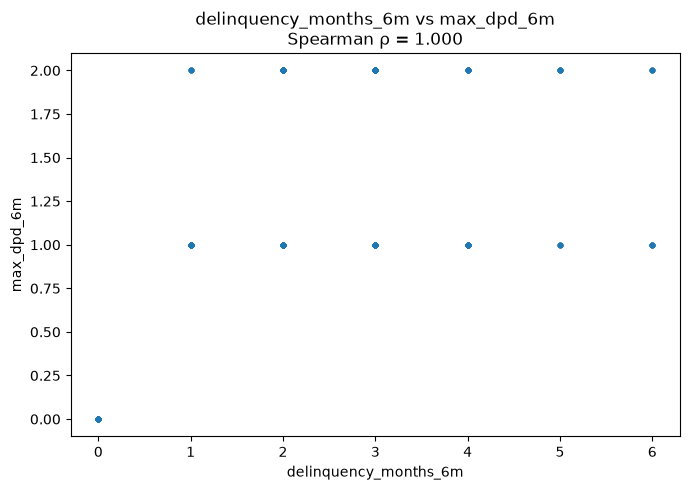

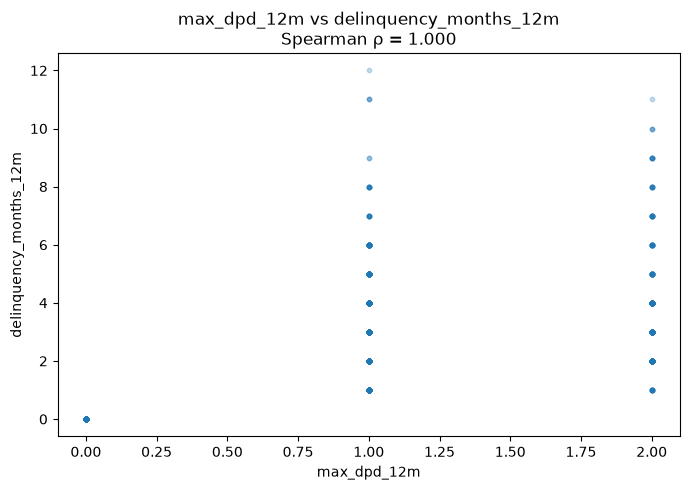

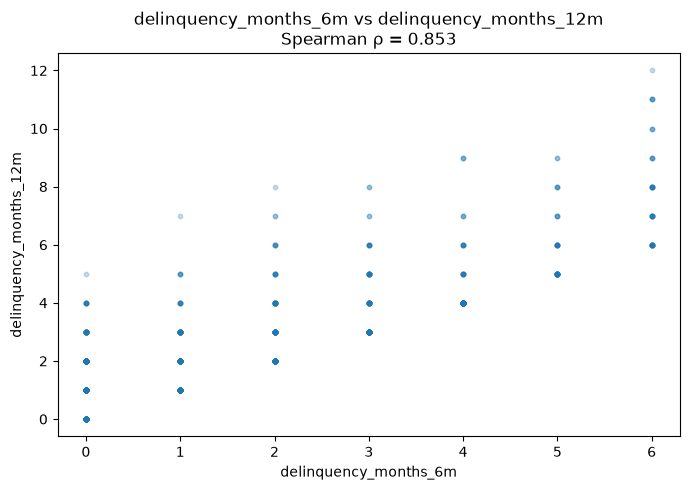

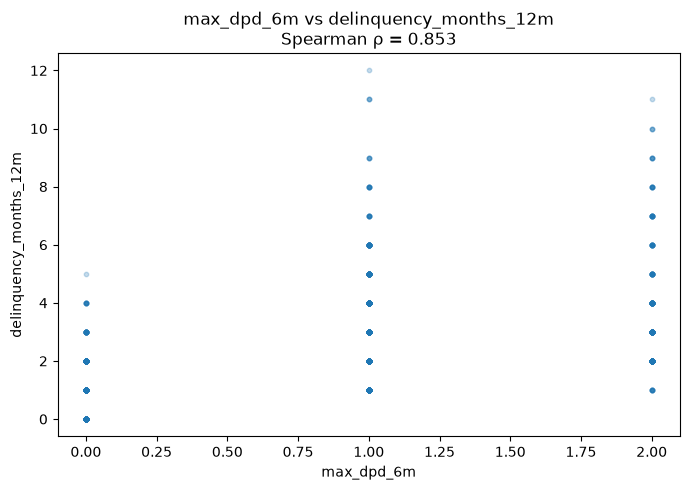

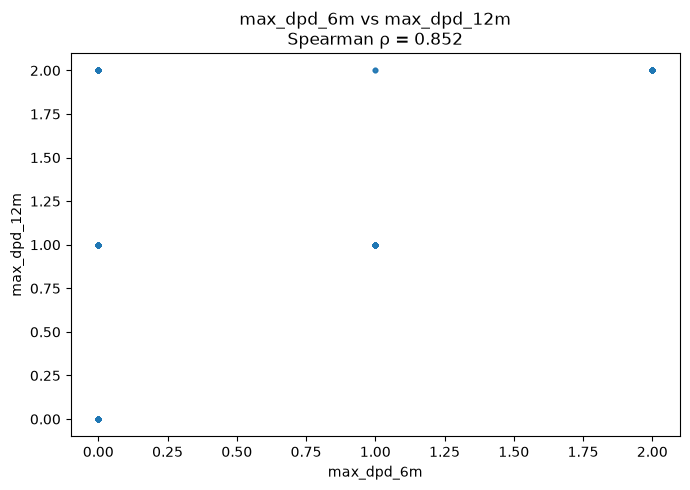

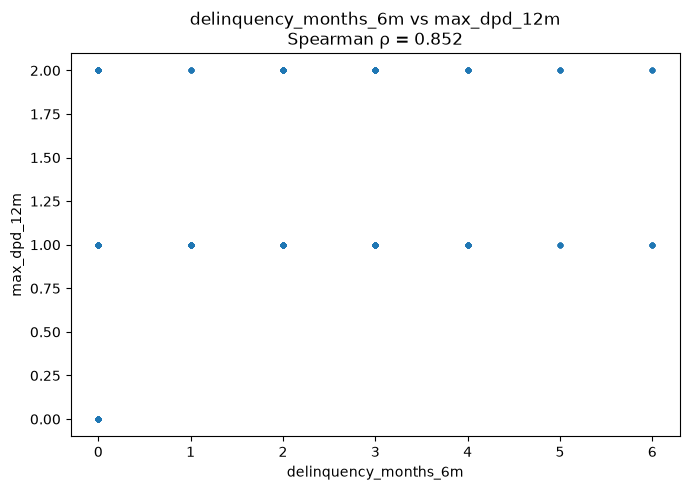

In [69]:
for _, row in strong_pairs_df.head(6).iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]

    plot_df = oot_corr_pd[[f1, f2]].dropna()

    if plot_df.empty:
        continue

    plt.figure(figsize=(7, 5))
    plt.scatter(plot_df[f1], plot_df[f2], alpha=0.25, s=10)
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(f"{f1} vs {f2}\nSpearman ρ = {row['spearman_corr']:.3f}")
    plt.tight_layout()
    plt.show()

In [70]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)

    if table.empty:
        return np.nan

    observed = table.to_numpy(dtype=float)
    n = observed.sum()

    if n <= 1:
        return np.nan

    row_sums = observed.sum(axis=1, keepdims=True)
    col_sums = observed.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / n

    valid = expected > 0
    chi2 = ((observed - expected) ** 2 / np.where(valid, expected, 1)).sum()

    phi2 = chi2 / n
    r, k = observed.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(kcorr - 1, rcorr - 1)

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2corr / denominator)


categorical_pairs = []

for i, feature_a in enumerate(categorical_features_used):
    for feature_b in categorical_features_used[i + 1 :]:
        x = oot_corr_pd[feature_a].fillna("Unknown").astype(str)
        y = oot_corr_pd[feature_b].fillna("Unknown").astype(str)

        categorical_pairs.append(
            {
                "feature_1": feature_a,
                "feature_2": feature_b,
                "cramers_v": cramers_v(x, y),
            }
        )

categorical_overlap_df = (
    pd.DataFrame(categorical_pairs)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

display(categorical_overlap_df)

,feature_1,feature_2,cramers_v
0,mi_cancellation_indicator,first_time_homebuyer_flag,0.470213
1,occupancy_status,first_time_homebuyer_flag,0.145301
2,property_state,mi_cancellation_indicator,0.090520
3,property_state,occupancy_status,0.090403
4,property_state,first_time_homebuyer_flag,0.089761
5,occupancy_status,mi_cancellation_indicator,0.087481
6,borrower_assistance_plan,occupancy_status,0.000000
7,borrower_assistance_plan,property_state,0.000000
8,borrower_assistance_plan,mi_cancellation_indicator,0.000000
9,borrower_assistance_plan,first_time_homebuyer_flag,0.000000


In [71]:
def correlation_ratio(categories, values):
    tmp = pd.DataFrame(
        {
            "category": categories,
            "value": values,
        }
    ).dropna()

    if tmp.empty:
        return np.nan

    values = tmp["value"].astype(float)
    grand_mean = values.mean()

    grouped = tmp.groupby("category")["value"]
    counts = grouped.size()
    means = grouped.mean()

    numerator = (counts * (means - grand_mean) ** 2).sum()
    denominator = ((values - grand_mean) ** 2).sum()

    if denominator == 0:
        return 0.0

    return float(np.sqrt(numerator / denominator))


mixed_pairs = []

for cat in categorical_features_used:
    for num in numeric_features:
        mixed_pairs.append(
            {
                "categorical_feature": cat,
                "numeric_feature": num,
                "eta": correlation_ratio(
                    oot_corr_pd[cat],
                    oot_corr_pd[num],
                ),
            }
        )

mixed_overlap_df = (
    pd.DataFrame(mixed_pairs).sort_values("eta", ascending=False).reset_index(drop=True)
)

display(mixed_overlap_df.head(30))

,categorical_feature,numeric_feature,eta
0,borrower_assistance_plan,months_since_last_delinquency,0.263008
1,borrower_assistance_plan,delinquency_months_6m,0.224207
2,first_time_homebuyer_flag,current_interest_rate,0.201457
3,mi_cancellation_indicator,current_interest_rate,0.177173
4,borrower_assistance_plan,delinquency_months_12m,0.166617
5,borrower_assistance_plan,calculated_loan_age,0.158032
6,occupancy_status,current_interest_rate,0.150643
7,property_state,original_dti,0.131580
8,borrower_assistance_plan,original_dti,0.129658
9,property_state,months_since_last_delinquency,0.118029


In [72]:
if permutation_df is not None and not numeric_corr.empty:
    max_abs_corr = {}

    for feature in numeric_features:
        others = numeric_corr.loc[feature].drop(labels=[feature], errors="ignore")
        max_abs_corr[feature] = others.abs().max() if not others.empty else np.nan

    summary_df = permutation_df.copy()

    if "feature" not in summary_df.columns and "original_feature" in summary_df.columns:
        summary_df = summary_df.rename(columns={"original_feature": "feature"})

    summary_df["max_abs_spearman_corr"] = summary_df["feature"].map(max_abs_corr)

    summary_df["redundancy_flag"] = np.select(
        [
            summary_df["max_abs_spearman_corr"] >= 0.90,
            summary_df["max_abs_spearman_corr"] >= 0.80,
            summary_df["max_abs_spearman_corr"] >= 0.50,
        ],
        ["VERY HIGH", "HIGH", "MODERATE"],
        default="LOW",
    )

    cols = [
        "feature",
        "gain_pct",
        "mean_auc_drop",
        "std_auc_drop",
        "mean_pr_auc_drop",
        "std_pr_auc_drop",
        "max_abs_spearman_corr",
        "redundancy_flag",
    ]

    display(
        summary_df[[c for c in cols if c in summary_df.columns]].sort_values(
            "mean_auc_drop", ascending=False
        )
    )
else:
    print("Combined table requires `results` and numeric features.")

,feature,gain_pct,mean_auc_drop,std_auc_drop,mean_pr_auc_drop,std_pr_auc_drop,max_abs_spearman_corr,redundancy_flag
8,credit_score,464.163544,0.059931,0.002390,0.018567,0.002563,0.215369,LOW
5,current_interest_rate,861.583130,0.016535,0.002095,-0.004340,0.003287,0.215369,LOW
12,number_of_borrowers,250.451141,0.015592,0.001801,0.008756,0.001387,0.060576,LOW
2,max_dpd_6m,1877.875977,0.010823,0.000406,0.126746,0.001236,0.999963,VERY HIGH
3,max_dpd_12m,1817.726807,0.010335,0.000451,0.047582,0.000913,0.999930,VERY HIGH
13,original_dti,249.466583,0.007575,0.001035,0.002005,0.001423,0.176333,LOW
7,property_state,517.349243,0.006068,0.002449,-0.000353,0.002212,NaN,LOW
0,delinquency_months_6m,5747.026855,0.003046,0.000309,0.057534,0.001121,0.999963,VERY HIGH
10,occupancy_status,344.845001,0.001340,0.000441,0.000348,0.000428,NaN,LOW
9,delinquency_months_12m,400.863556,0.000714,0.000065,0.006291,0.000168,0.999930,VERY HIGH
